In [25]:
%pip install -q ultralytics matplotlib

Note: you may need to restart the kernel to use updated packages.


In [26]:
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd


In [27]:
model = YOLO("yolo11n.pt")


In [28]:
image_dir = Path("images")
image_paths = sorted(
    [
        p
        for p in image_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
    ]
)
[len(image_paths), [p.name for p in image_paths]]


[10,
 ['image1.png',
  'image2.png',
  'image3.png',
  'image4.png',
  'image5.png',
  'image6.png',
  'image7.png',
  'image8.png',
  'image9.png',
  'image91.png']]

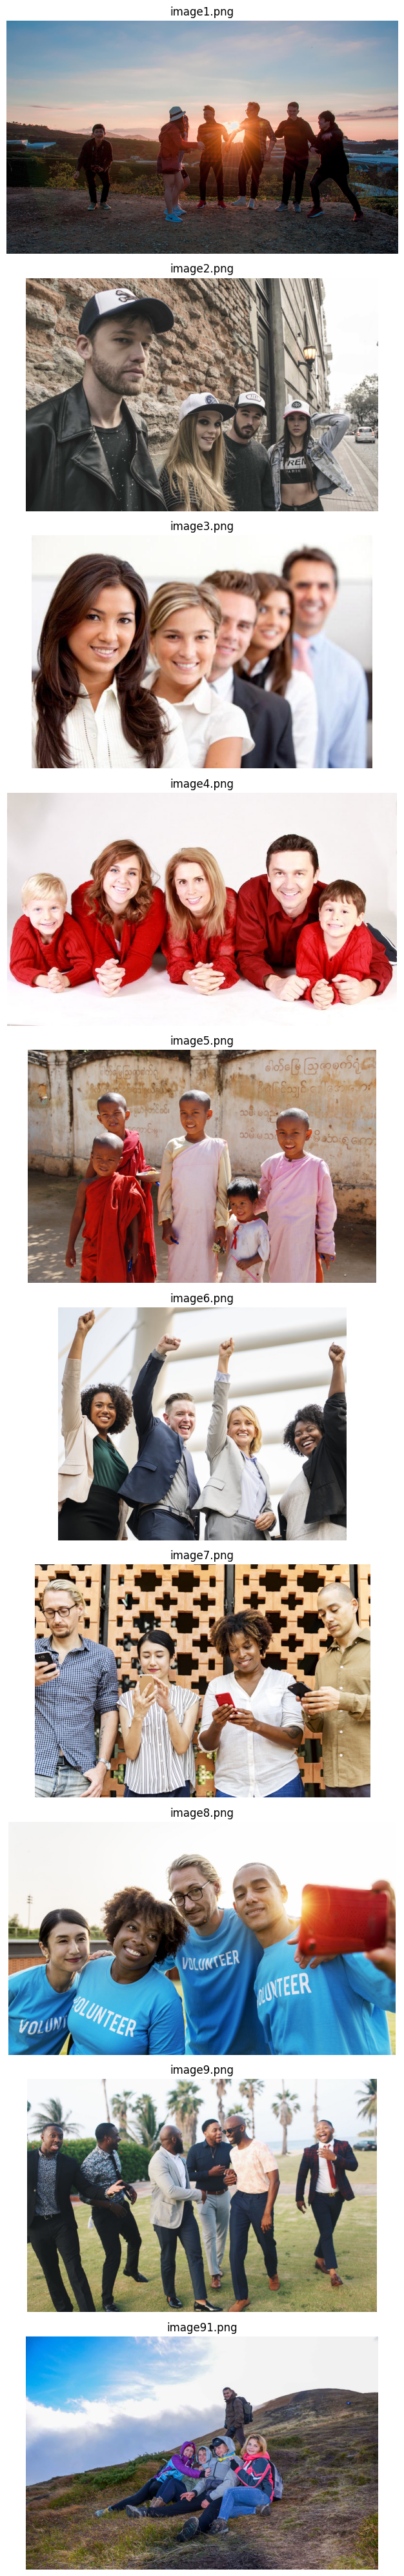

In [29]:
fig, axes = plt.subplots(len(image_paths), 1, figsize=(10, 4 * len(image_paths)))

if len(image_paths) == 1:
    axes = [axes]

for ax, path in zip(axes, image_paths):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [30]:
results = model.predict([str(p) for p in image_paths], conf=0.8, verbose=False)


In [31]:
pred_counts = []

for path, result in zip(image_paths, results):
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        count = 0
    else:
        cls = boxes.cls.cpu().numpy().astype(int)
        count = int((cls == 0).sum())
    pred_counts.append(count)

pd.DataFrame({"image": [p.name for p in image_paths], "pred_persons": pred_counts})


,image,pred_persons
0,image1.png,6
1,image2.png,2
2,image3.png,4
3,image4.png,5
4,image5.png,4
5,image6.png,2
6,image7.png,4
7,image8.png,4
8,image9.png,6
9,image91.png,1


In [32]:
actual_counts = [7, 4, 5, 5, 5, 4, 4, 4, 6, 5]


In [33]:
tp = sum(min(a, p) for a, p in zip(actual_counts, pred_counts))
fp = sum(max(p - a, 0) for a, p in zip(actual_counts, pred_counts))
fn = sum(max(a - p, 0) for a, p in zip(actual_counts, pred_counts))
tn = 0

tp, fp, fn, tn


(38, 0, 11, 0)

In [34]:
confusion_matrix = pd.DataFrame(
    [[tp, fp], [fn, tn]],
    index=["Pred True", "Pred False"],
    columns=["Actual True", "Actual False"],
)

confusion_matrix


,Actual True,Actual False
Pred True,38,0
Pred False,11,0


In [35]:
precision = tp / (tp + fp) if tp + fp > 0 else 0
recall = tp / (tp + fn) if tp + fn > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0

round(precision, 3), round(recall, 3), round(f1, 3)


(1.0, 0.776, 0.874)

In [36]:
round(f1, 3)


0.874